In [1]:

import pandas as pd 
import geopandas as gpd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns 

import solara
from mesa import Agent, Model
from mesa.space import ContinuousSpace
from mesa.visualization import SolaraViz, make_plot_component, make_space_component
from mesa.visualization.utils import update_counter
from mesa.datacollection import DataCollector
from mesa.batchrunner import batch_run



from shapely.geometry import LineString, Point
from shapely.affinity import translate

from scipy.stats import truncnorm
import random

import mesa
pd.set_option('display.max_rows', 1000)


# Load road and modify

## make api request

In [2]:
# Define the base URL and parameters
base_url = "https://maps.udot.utah.gov/central/rest/services/TrafficAndSafety/UDOT_Speed_Limits/MapServer/0/query"
params = {
    "where": "Name='0210'",
    "outFields": "*",
    "f": "json"
}

# Make the GET request
response = requests.get(base_url, params=params)

# Check if the request was successful
if response.status_code == 200:
    data  = response.json()
    features = data['features']
    # Process the data as needed
else:
    print(f"Error: {response.status_code}")


## convert to a gdf of points

In [3]:
# old file no longer used
# road_gdf = gpd.read_file("hw210.geojson")

geoms = []
speed_limits = []
# this loops through the api request and gets the paths and speed limits
for feature in features:
    paths = feature["geometry"]["paths"]
    for path in paths:
        geoms.append(LineString(path))
        speed_limits.append(feature["attributes"]["Speed_Limit"])

# saves the data in a gdf 
gdf = gpd.GeoDataFrame({"speed_limit": speed_limits}, geometry=geoms, crs="EPSG:26912").to_crs('EPSG:4326')

# i drop the snowbird loop
gdf = gdf.drop(1).reset_index(drop=True) 

# reorder the rows so that the points are in order
gdf = gdf.reindex([3, 2, 1, 0]).reset_index(drop=True)

# now explode the coords
exploded = gdf.copy()
exploded["geometry"] = exploded["geometry"].apply(lambda line: list(line.coords))
# Explode into rows (flatten list of coordinates)
exploded = exploded.explode("geometry").reset_index(drop=True)
# Convert each coordinate into a Point geometry
exploded["geometry"] = exploded["geometry"].apply(lambda coord: Point(coord))
# Convert to GeoDataFrame with same CRS and keep speed limits
w_speed_limits = gpd.GeoDataFrame(exploded, geometry="geometry", crs=gdf.crs)

w_speed_limits['linked_coord'] = None
w_speed_limits.head(3)

/var/folders/3k/nps11w_s51g1hd6h7mpjr2b40000gn/T/ipykernel_25034/2873861598.py:24: UserWarning: Geometry column does not contain geometry.
  exploded["geometry"] = exploded["geometry"].apply(lambda line: list(line.coords))


,speed_limit,geometry,linked_coord
0,50,POINT (-111.78947 40.61933),None
1,50,POINT (-111.78938 40.61853),None
2,50,POINT (-111.78913 40.61752),None


## create down lane

In [4]:
# reverse the gdf 
reverse_w_speed_limits = w_speed_limits[::-1].to_crs(epsg=32612)
# shift the road over
reverse_w_speed_limits["geometry"] = reverse_w_speed_limits["geometry"].apply(lambda geom: translate(geom, xoff=300, yoff=500)).to_crs(epsg=4326)
# concat them together
full_road = pd.concat([w_speed_limits, reverse_w_speed_limits]).reset_index(drop=True)



# adding a col that links the up and down lanes 
full_road['linked_coord'] = full_road.geometry[::-1 ].reset_index(drop=True)



## final road deffinition

In [5]:
# vvvv-----vvvv here is the actual road im using
road_gdf = w_speed_limits # other options is: full_road

# distilling the the road 
every_nth_point = 1
road_gdf = road_gdf.iloc[::every_nth_point, :].reset_index(drop=True)

number of road points: 427

GDF Head


,speed_limit,geometry,linked_coord
0,50,POINT (-111.78947 40.61933),None
1,50,POINT (-111.78938 40.61853),None
2,50,POINT (-111.78913 40.61752),None


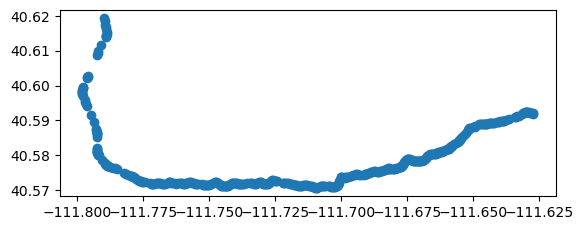

In [6]:
print(f'number of road points: {len(road_gdf)}')
road_gdf.plot()
print('')
print('GDF Head')
display(road_gdf.head(3))

# Agent helper functions

In [46]:
def get_dps(mph): 
    mps =mph/3600.0 # 3600 secounds in an hour
    dps = mps/69 # 69 miles in a degree 
    return dps

def get_mph(dps): 
    dph =dps*3600.0 # 3600 mins in an hour
    mph = dph*69 # 69 miles in a degree 
    return mph


def get_acceleration(current_speed, max_speed=get_dps(60), max_accel=get_dps(4)):
    """
    Estimate acceleration in degrees per minute based on current speed.

    Parameters:
        current_speed (float): Current speed in degrees per secound
        max_speed (float): Max speed in degrees per secound
        max_accel (float): Peak acceleration in mph/s defaults to a change in 4 mph/sec.

    Returns:
        float: Acceleration in degrees per minute²
    """
    # Normalize current speed as a fraction of max speed
    x = current_speed / max_speed
    x = np.clip(x, 0, 1)
    # Logistic-shaped acceleration curve (derivative of sigmoid)
    accel = max_accel * (1 - x) * x * 4  # Scaling factor 4 centers the peak at 0.5
    return accel

def get_deceleration(how='soft'):
    options = {'soft': get_dps(1), #~1mph/s 
               'normal': get_dps(2.5), #~2.5mph/s
               'hard': get_dps(5) #~5mph/s
              }
    return  options[how]
    
    


# Road agent

In [47]:
class RoadSegmentAgent(mesa.Agent):
    """Represents a segment of the road. Only one car can occupy it at a time."""
    
    def __init__(self, model, position, speed_limit, linked_coord):
        super().__init__(model)
        self.position = position  # The index of the segment
        self.occupied = False  # Whether a car is on this segment
        self.status = 'im just a road'
        self.speed_limit = speed_limit
        self.linked_coord = linked_coord

    def step(self):
        """Tracks occupancy but does not move."""
        pass

# VehicleAgent base class

In [75]:
class VehicleAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.status = "driving"
        self.speed = get_dps(10) # starting speed
        
        # For data collection 
        self.created_at_step = self.model.steps 
        self.steps_taken = 0 
        self.distance_traveled = 0
        self.car_interactions = 0

        # These will be set in subclasses
        self.max_speed = None
        self.ideal_distance_multiplier = None
        self.acceptable_over = None

        # Speed control tuning parameters (can be overridden)
        self.jitter_threshold = get_dps(2)
        self.jitter_variance = get_dps(0.2)
        self.max_acceleration = get_dps(4)
        self.min_speed = get_dps(1)
        self.deceleration_mode = 'normal'

        # init all the road segement data 
        self.road_segments = self.model.agents.select(agent_type=RoadSegmentAgent)

        # Establish the Vehicles positio n 
        self.path = self.road_segments.get('position')
        self.path_index = 0
        self.model.space.place_agent(self, self.path[0])  # <-- here is the intial place agent

        
    def end_of_road(self):
        '''If at the last segment, remove the car'''
        if self.path_index >= len(self.path) - 1:
            self.status = "arrived"
            
            self.model.finished_agents.append({
                "AgentID": self.unique_id,
                "created_at_step": self.created_at_step,
                "steps_taken": self.steps_taken,
                "car_interactions": self.car_interactions, 
                "distance_traveled": self.distance_traveled*69 , # times 69 to convert ~miles
                "approx_average_mph": (self.distance_traveled*69)/(self.steps_taken/3600), 
                "acceptable_over": get_mph(self.acceptable_over),
                "ideal_distance_multiplier":self.ideal_distance_multiplier
            # Add more if needed
            })
            self.remove() 
            return True
        
    def get_gap(self):
            """
            Returns:
                ideal_gap: float — the desired following distance (deg)
                gap: float — distance to the closest vehicle ahead (deg)
            """
            ideal_gap = self.speed * self.ideal_distance_multiplier  
            
            other_vehicles = self.model.agents.select(agent_type=VehicleAgent)
            cars_ahead = [
                agent for agent in other_vehicles
                if agent.distance_traveled > self.distance_traveled
            ]
            
            if cars_ahead:
                next_agent = min(cars_ahead, key=lambda agent: agent.distance_traveled)
                gap = Point(self.pos).distance(Point(next_agent.pos))
            else:
                gap = float("inf")

            if not np.isfinite(gap):
                gap = float("inf")
            
            return ideal_gap, gap
        
    def get_speed_limit(self):
        return get_dps(self.road_segments[self.path_index].speed_limit) + self.acceptable_over

    def smooth_brake(self, gap, ideal_gap):
        """
        Calculate deceleration based on a smooth braking rule,
        where speed and distance are in degrees per second and degrees.
        """
        if ideal_gap <= 0 or np.isnan(ideal_gap):
            force = 0
        else:
            force = max((ideal_gap - gap)/ideal_gap, 0) # this produces a number between 0 and 1
        # Ideal following distance in degrees: assume 1.5 seconds of headway
        deceleration = force * get_dps(5) # <- this is acting as max decel 
        return deceleration
            
    def adjust_speed(self):
        ideal_gap, gap  = self.get_gap()        
        speed_limit = self.get_speed_limit()

        if gap < ideal_gap:
            self.car_interactions += 1
            self.speed -= max(self.smooth_brake(gap=gap, ideal_gap=ideal_gap), get_deceleration(how=self.deceleration_mode))
        elif abs(self.speed - speed_limit) < self.jitter_threshold:
            self.speed += self.random.normalvariate(0, self.jitter_variance)
        elif self.speed > speed_limit:
            self.speed = max(self.speed - get_deceleration(how=self.deceleration_mode), self.min_speed)
        elif self.speed < self.max_speed:
            self.speed += min(get_acceleration(self.speed, self.max_speed, self.max_acceleration), speed_limit - self.speed)

        self.speed = max(self.speed, self.min_speed)

    def move_along_path(self):
        """Move the agent along its predefined path based on current speed."""
        distance_to_travel = self.speed
        self.distance_traveled += distance_to_travel
        pos = np.array(self.pos)
        new_position = pos
        
        while distance_to_travel > 0 and not self.end_of_road():
            next_target = np.array(self.path[self.path_index + 1])
            direction = next_target - pos
            distance = np.linalg.norm(direction)
    
            if distance < distance_to_travel:
                self.path_index += 1
                distance_to_travel -= distance
                pos = next_target
                new_position = pos
            else:
                step_vector = distance_to_travel * direction / distance
                new_position = pos + step_vector
                distance_to_travel = 0
    
        self.model.space.move_agent(self, tuple(new_position))


    def step(self):
        if self.status == "arrived":
            return 
        
        self.steps_taken += 1  
        self.adjust_speed()
        self.move_along_path()


# Car Agent

In [76]:
class CarAgent(VehicleAgent):
    """Represents a car moving in the canyon."""
    def __init__(self, model, road_points_gdf):
        super().__init__(model)
        self.status = "driving"  # the initial status of the car
        
        # speed perams
        self.max_speed = get_dps(80)
        self.acceptable_over = get_dps(truncnorm((-2 - 3)/4, (20 - 3)/4, loc=3, scale=4).rvs()) # this is a right skewed normal dist bounded by (-2,20)
        self.ideal_distance_multiplier = truncnorm((1.2 - 1.5)/.2, (2.5 - 1.5)/.2, loc=1.5, scale=.2).rvs()
        
        # Speed control tuning parameters 
        self.jitter_threshold = get_dps(3)
        self.jitter_variance = get_dps(0.2)
        self.max_acceleration = get_dps(4)
        self.min_speed = get_dps(1)
        self.deceleration_mode = 'normal'

    
        
class BusAgent(VehicleAgent):
    """Represents a bus moving in the canyon."""
    def __init__(self, model, road_points_gdf):
        super().__init__(model)
        self.status = "driving"  # the initial status of the car
        
        # speed perams
        self.max_speed = get_dps(60)
        self.acceptable_over = 0
        self.ideal_distance_multiplier = 2.5
        
        # Speed control tuning parameters 
        self.jitter_threshold = get_dps(3)
        self.jitter_variance = get_dps(0.2)
        self.max_acceleration = get_dps(1.5)
        self.min_speed = get_dps(1)
        self.deceleration_mode = 'normal'

    

# Model 

In [94]:

class TrafficModel(mesa.Model):
    """Mesa model simulating traffic on the canyon road with a car cap."""

    def __init__(self, road_points_gdf=road_gdf, p_generate=.001, max_cars=50, max_steps=50000, seed=None, log_agents=False):
        super().__init__(seed=seed)
        self.log_agents = log_agents
        self.p_generate = p_generate  # Probability of new car each step
        self.max_cars = max_cars  # Maximum number of cars allowed
        self.road_points_gdf = road_points_gdf
        self.max_steps = max_steps
        
        # verious trackers
        self.too_close_tracker = 0 
        self.cars_generated = 0 
        self.finished_agents = [] 
            
        # Set up ContinuousSpace
        buffer = .0001
        minx, miny, maxx, maxy = road_points_gdf.total_bounds
        self.space = ContinuousSpace(
            x_min=minx - buffer,
            x_max=maxx + buffer,
            y_min=miny - buffer,
            y_max=maxy + buffer,
            torus=False
        )

        # Create road segment agents - this just creates them in a loop setting the position via the gdf point
        self.road_segments = RoadSegmentAgent.create_agents( 
            model=self, 
            n=len(self.road_points_gdf), 
            position=[(point.x, point.y) for point in self.road_points_gdf.geometry], # need to be passed as a list
            speed_limit=[speed_limit for speed_limit in self.road_points_gdf.speed_limit],
            linked_coord=[linked_coord for linked_coord in self.road_points_gdf.linked_coord]
        )
        # place all the road segments in space - goes hand in hand with read point reation 
        for agent, point in zip(self.road_segments, road_points_gdf.geometry):self.space.place_agent(agent, (point.x, point.y))

        # establish the data collector 
        agent_reporters={
            "AgentType": lambda a: a.__class__.__name__ ,
            'speed': lambda a: get_mph(a.speed) if isinstance(a, CarAgent) else None,
            'steps_taken': lambda a: a.steps_taken if isinstance(a, CarAgent) else None,
            'hrs': lambda a: a.steps_taken/3600 if isinstance(a, CarAgent) else None,
            #'distance_traveled': lambda a: a.distance_traveled if isinstance(a, CarAgent) else None,
            #'acceptable_over': lambda a: get_mph(a.acceptable_over) if isinstance(a, CarAgent) else None,
            #'ideal_distance_multiplier': lambda a: a.ideal_distance_multiplier if isinstance(a, CarAgent) else None,
        }

        model_reporters={
            "cars_generated": lambda m: m.cars_generated,
            "too_close_tracker": lambda m: m.too_close_tracker, 
            "FinishedAgentsSummary": lambda m: None  # Placeholder
        }

        if log_agents:
            self.datacollector = DataCollector(
                model_reporters = model_reporters, 
                agent_reporters = agent_reporters
            )
        else: 
            self.datacollector = DataCollector(model_reporters = model_reporters)
    
        
    def generate_new_car(self):
        # Only generate if under max limit
        if self.cars_generated >= self.max_cars:
            return
        # Get the starting point
        start_point = self.road_points_gdf.iloc[0].geometry.coords[0]  
        
        # Check if another car is too close to the start
        too_close = any(
            self.space.get_distance(agent.pos, start_point) < (5/100000) # m -> degrees
            for agent in self.agents.select(agent_type=CarAgent)[-5:]
        )
        if too_close:
            self.too_close_tracker += 1
        elif self.random.random() < self.p_generate:
            CarAgent.create_agents(model=self, n=1, road_points_gdf=self.road_points_gdf)
            self.cars_generated += 1
    
    def model_stop_process(self):
        # add agent summary data to the datacollector
        self.datacollector.model_vars["FinishedAgentsSummary"][-1] = self.finished_agents
        self.running = False
        
    def step(self):
        # Collect data before stepping
        self.datacollector.collect(self)

        # generate a new car based on a simple probability 
        self.generate_new_car()

        # Shuffle agent execution and step them - this calls the step functions of the agents
        self.agents.shuffle_do("step")

        # Stop model when all generated cars have been removed
        if self.cars_generated == self.max_cars:
            remaining_cars = self.agents.select(agent_type=VehicleAgent)
            if len(remaining_cars) == 0:
                print("All cars have been removed. Stopping model.")
                self.model_stop_process()
        
        # Stop model at hard cap of steps
        if self.steps >= self.max_steps:
            print(f"Reached max step count ({self.max_steps}). Stopping model.")
            self.model_stop_process()
             


# Simple model run (fast)

In [95]:
%%time
model = TrafficModel(road_points_gdf=road_gdf, p_generate=0.1, max_cars=100, max_steps=10000, log_agents=False)

while model.running: 
    model.step()

#for i in range(15):
#    model.step()


print(f'Model ran for {model.steps} steps')



All cars have been removed. Stopping model.
Model ran for 8577 steps
CPU times: user 14.7 s, sys: 166 ms, total: 14.9 s
Wall time: 14.9 s


## Analyze data

In [91]:
finished_agents = pd.DataFrame(model.finished_agents)
finished_agents =finished_agents.sort_values(by='AgentID')
#make a travel time
finished_agents["travel_time"] = pd.to_timedelta(finished_agents["steps_taken"], unit="s").astype(str).str.extract(r'(\d+:\d{2})')
# rounding
round_cols = ['distance_traveled', 'approx_average_mph','acceptable_over', 'ideal_distance_multiplier']
finished_agents[round_cols] = round(finished_agents[round_cols], 2)

finished_agents["steps_behind_previous"] = finished_agents["created_at_step"].diff().fillna(0).astype(int)
finished_agents["pct_car_interactions"] = finished_agents.car_interactions/finished_agents.steps_taken
print(f'N cars: {len(finished_agents)}, fake hours: {round(model.steps/3600,1)}')
finished_agents.tail() 

N cars: 100, fake hours: 2.4


,AgentID,created_at_step,steps_taken,car_interactions,distance_traveled,approx_average_mph,acceptable_over,ideal_distance_multiplier,travel_time,steps_behind_previous,pct_car_interactions
86,523,1073,1598,636,15.08,33.98,7.26,1.88,00:26,26,0.397997
83,524,1087,1519,134,15.08,35.74,0.87,1.64,00:25,14,0.088216
85,525,1102,1525,307,15.09,35.61,5.12,1.55,00:25,15,0.201311
91,526,1110,1703,219,15.08,31.89,-1.33,1.69,00:28,8,0.128597
92,527,1119,2243,616,15.08,24.21,6.25,1.26,00:37,9,0.274632


N cars: 100


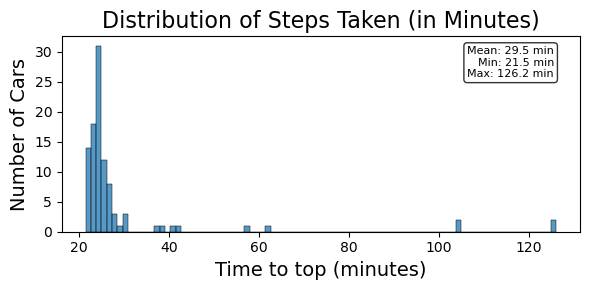

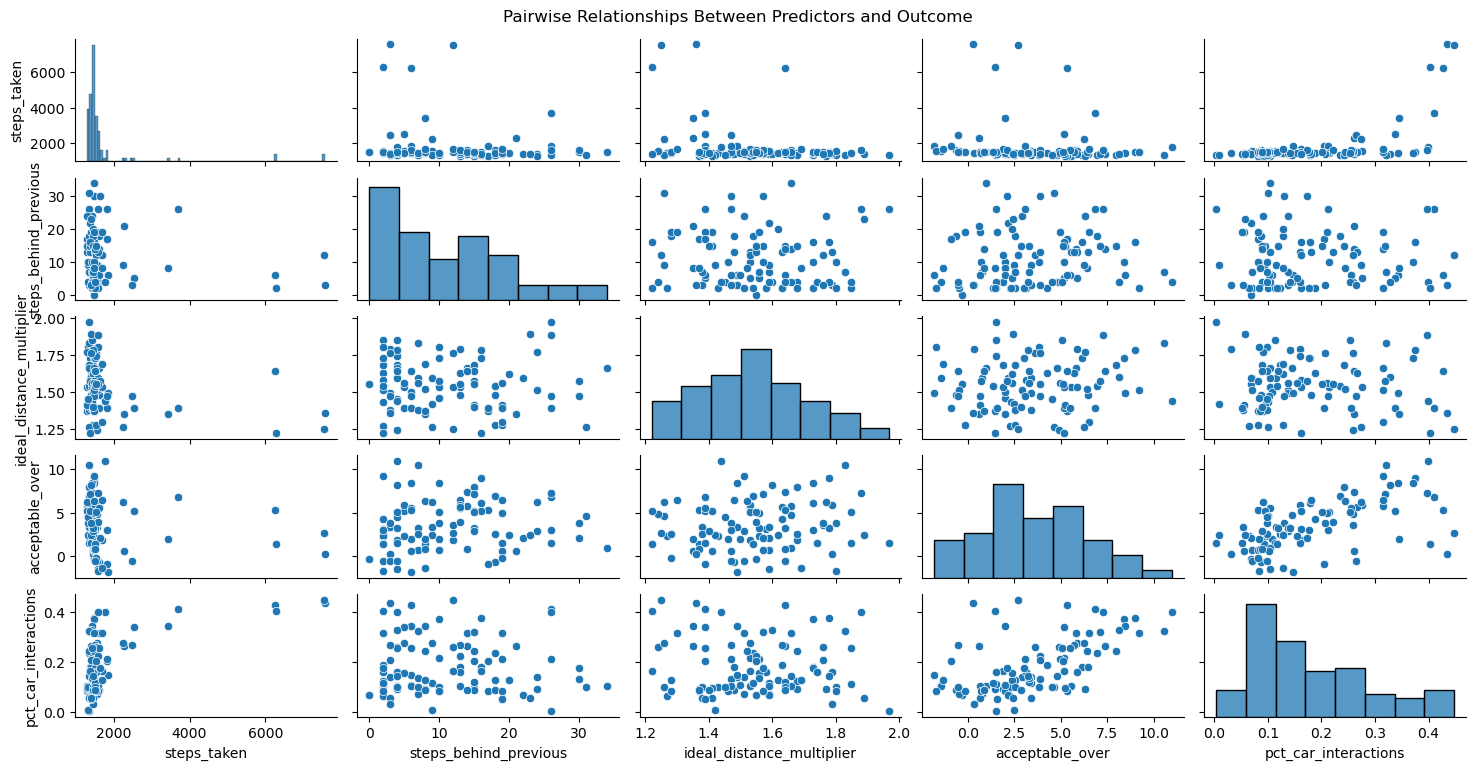

In [96]:
print(f'N cars: {len(finished_agents)}')

# Convert to minutes
times = finished_agents.steps_taken / 60

# Compute summary stats
mean_time = times.mean()
min_time = times.min()
max_time = times.max()

# --- Histogram ---
plt.figure(figsize=(6, 3))
sns.histplot(times)

# Title and axis labels
plt.title("Distribution of Steps Taken (in Minutes)", fontsize=16)
plt.xlabel("Time to top (minutes)", fontsize=14)
plt.ylabel("Number of Cars", fontsize=14)

# Add stats box
textstr = f"Mean: {mean_time:.1f} min\nMin: {min_time:.1f} min\nMax: {max_time:.1f} min"
plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=8, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# --- Pairplot ---
sns.pairplot(finished_agents[[
    "steps_taken", 
    "steps_behind_previous", 
    "ideal_distance_multiplier", 
    "acceptable_over", 
    "pct_car_interactions"
]], height=1.5,     # default is 2.5; smaller = smaller plot
    aspect=2 )
plt.suptitle("Pairwise Relationships Between Predictors and Outcome", y=1.02)
plt.show()

/Users/zanderholleran/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            steps_taken   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     26.36
Date:                Thu, 03 Apr 2025   Prob (F-statistic):            0.00368
Time:                        20:28:55   Log-Likelihood:                -37.986
No. Observations:                  10   AIC:                             87.97
Df Residuals:                       4   BIC:                             89.79
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                  1498.5360     64.189     23.346      0.000    1320.319    1676.753
steps_behind_previous        -0.2693      0.762     -0.353      0.742      -2.386       1.847
ideal_distance_multiplier   -62.9393     39.877     -1.578      0.190    -173.656      47.778
acceptable_over             -42.2907      7.479     -5.655      0.005     -63.055     -21.526
pct_car_interactions        879.1471    281.678      3.121      0.035      97.083    1661.211
created_at_step               0.2469      0.328      0.752      0.494      -0.665       1.158
==============================================================================
Omnibus:                        0.960   Durbin-Watson:                   1.923
Prob(Omnibus):                  0.619   Jarque-Bera (JB):                0.437
Skew:                           0.483   Prob(JB):                        0.804
Kurtosis:                       2.660   Cond. No.                     4.56e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.56e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

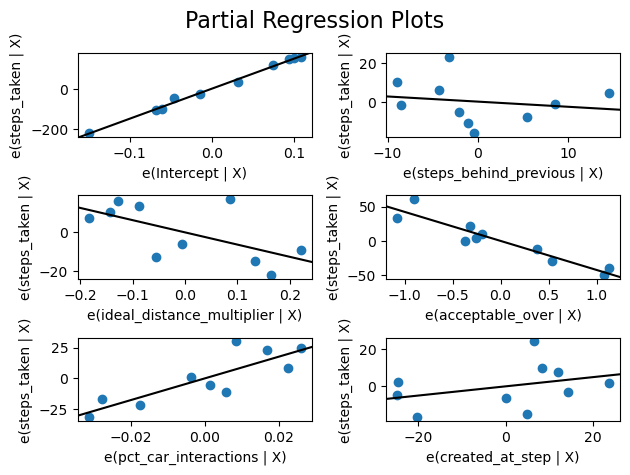

In [86]:
# Fit a marginal model using OLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
model = smf.ols("steps_taken ~ steps_behind_previous + ideal_distance_multiplier + acceptable_over + pct_car_interactions + created_at_step", data=finished_agents).fit()

# Partial regression plots to understand marginal contributions
fig = sm.graphics.plot_partregress_grid(model)
fig.suptitle("Partial Regression Plots", fontsize=16)
fig.tight_layout()

model.summary()


# Model Exe w/ live anamation)

In [101]:
%%time 
# this has to portrayal logic for all the agents
def agent_portrayal(agent):
    if isinstance(agent, CarAgent):
        return {
            "color": "red",
            "size": 15,
        }
    elif isinstance(agent, RoadSegmentAgent):
        return {
            "color": "blue",
            "size": 5,
        }
    return {}
    


# Create the actual model instance with real values (not Slider dicts)
model = TrafficModel(road_points_gdf=road_gdf, p_generate=0.1, max_cars=100, max_mph=60, max_steps=300000, log_agents=False)

# UI controls – only expose max_cars
model_params = {
    "max_cars": {
        "type": "SliderInt",
        "value": 1,
        "label": "Number of Cars",
        "min": 1,
        "max": 500,
        "step": 1,
    },
    "p_generate": 0.1,
    "road_points_gdf": road_gdf,
    "max_mph": 60,
    "max_steps": 300000,
    "log_agents": False,
}

# the visulation 
SpaceGraph = make_space_component(agent_portrayal)
page = SolaraViz(
    model,
    components=[SpaceGraph],
    model_params=model_params,
    name="TrafficModel",
)
# This is required to render the visualization in the Jupyter notebook
page




CPU times: user 20 ms, sys: 10.1 ms, total: 30.1 ms
Wall time: 23.2 ms


Cannot show ipywidgets in text

# Batch run

In [ ]:
model = TrafficModel(road_points_gdf=road_gdf, p_generate=0.1, max_cars=20, max_mph=60, max_steps=300000, log_agents=False)


perams = {
    "road_points_gdf": road_gdf,
    'max_mph':60, 
    'max_steps':300000,
    'log_agents':False,
    "p_generate": [0.1, 0.001, 0.00001],
    "max_cars": [10, 50 ]
}




results = batch_run(
    model_cls=TrafficModel,
    parameters=perams,
    iterations=1,  # Run each config 5 times
    max_steps=10000,
    data_collection_period=-1,  # Collect at every step, -1 means collect all
    number_processes=1,
    display_progress=True
)



# Data export from model runs

In [ ]:
road_agents = model.agents.select(agent_type=RoadSegmentAgent)
road_features = road_agents.get(["occupied", "position", 'speed_limit'])
pd.DataFrame(road_features, columns=["occupied", "position", "speed_limit"])


road_segments = model.agents.select(agent_type=RoadSegmentAgent)
current_road = road_segments[2]
current_road.speed_limit

In [ ]:
model.agents[1].unique_id

In [ ]:
cars = model.agents.select(agent_type=CarAgent)
cars_ahead = [
    car for car in cars
    if car.path_index > 5
]

if cars_ahead:
    next_car = min(cars_ahead, key=lambda car: car.path_index)

next_car.pos

# Rando stuff

## request the road shape and speed limit

In [ ]:
mean = 1.5
std = .2
sns.histplot(truncnorm((1.2 - 1.5)/.2, (2.5 - 1.5)/.2, loc=1.5, scale=.2).rvs(4000))

In [ ]:
# Retrieve agent-level data as a DataFrame
agent_data = model.datacollector.get_agent_vars_dataframe()

# Filter to include only CarAgents
car_data = agent_data[agent_data.index.get_level_values("AgentID").isin(
    [agent.unique_id for agent in model.agents.select(agent_type=CarAgent)]
)]

car_data_reindex = car_data.reset_index()

len(car_data)

In [ ]:
car_data.columns

In [ ]:
%%time


# Define number of points to extract along the road
num_points = 20  # Adjust for granularity

# interpolate num_points onto the line segment
points = [road_geometry.interpolate(i / num_points, normalized=True) for i in range(num_points)]

# Convert to a GeoDataFrame
road_points_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")

# this is time consuming get the elevations
def get_elevation(lat, lon):
    """Fetch elevation data from Open-Elevation API."""
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()['results'][0]['elevation']
    else:
        return None

# Add elevation to each road point
road_points_gdf["latitude"] = road_points_gdf.geometry.y
road_points_gdf["longitude"] = road_points_gdf.geometry.x

# Fetch elevation
road_points_gdf["elevation"] = road_points_gdf.apply(lambda row: get_elevation(row.latitude, row.longitude), axis=1)


road_points_gdf.head()